# Ariel data challenge model evaluation

## 1. Notebooks set up

In [1]:
# Standard library imports
import os
import time

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FormatStrFormatter

# Project imports
from ariel_data_preprocessing.data_generator_functions import make_training_datasets

2025-09-23 12:05:43.016443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758629143.300748      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758629143.386680      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 2. Initalize data generators

In [2]:
sample_size = 372
n_samples = 10

_, _, evaluation_dataset = make_training_datasets(
    data_file='/kaggle/input/ariel-training-data/train.h5',
    sample_size=sample_size,
    n_samples=n_samples,
    validation=True
)

Creating new training/validation split


2025-09-23 12:06:01.540329: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. Create dataset

In [3]:
evaluation_data = evaluation_dataset.take(550)
signals = np.array([element[0].numpy() for element in evaluation_data])
spectra = np.array([element[1].numpy() for element in evaluation_data])

print(f'Signals shape: {signals.shape}')
print(f'Spectra shape: {spectra.shape}')

Signals shape: (550, 10, 372, 283)
Spectra shape: (550, 10, 283)


## 4. Load model

In [4]:
model = tf.keras.models.load_model('/kaggle/input/ariel-cnn/ariel-cnn-8.1M-862ksteps.keras')

## 5. Make predictions

In [5]:
spectrum_predictions = []

for planet in signals:
    spectrum_predictions.append(model.predict(planet, batch_size=10, verbose=0))

spectrum_predictions = np.array(spectrum_predictions)
spectrum_predictions_avg = np.mean(spectrum_predictions, axis=1)
spectrum_predictions_std = np.std(spectrum_predictions, axis=1)
reference_spectra = spectra[:,0,:]

print(f'Spectrum predictions shape: {spectrum_predictions.shape}')
print(f'Spectrum predictions avg shape: {spectrum_predictions_avg.shape}')
print(f'Spectrum predictions std shape: {spectrum_predictions_std.shape}')

I0000 00:00:1758629291.180919      56 service.cc:148] XLA service 0x7898fc008030 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758629291.183958      56 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1758629291.864358      56 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Spectrum predictions shape: (550, 10, 283)
Spectrum predictions avg shape: (550, 283)
Spectrum predictions std shape: (550, 283)


## 6. Evaluation

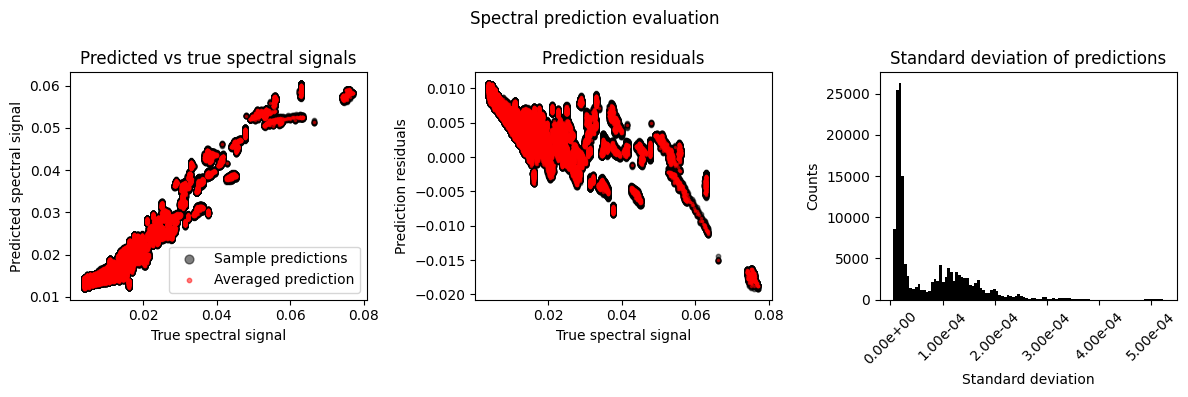

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

fig.suptitle('Spectral prediction evaluation')

axs[0].set_title('Predicted vs true spectral signals')
axs[0].scatter(
    spectra.flatten(),
    spectrum_predictions.flatten(),
    s=10,
    alpha=0.5,
    color='black',
    label='Sample predictions'
)
axs[0].scatter(
    reference_spectra.flatten(),
    spectrum_predictions_avg.flatten(),
    s=2.5,
    alpha=0.5,
    color='red', 
    label='Averaged prediction'
)
axs[0].set_xlabel('True spectral signal')
axs[0].set_ylabel('Predicted spectral signal')
axs[0].legend(loc='best', markerscale=2)

residuals = spectrum_predictions.flatten() - spectra.flatten()
avg_residual = spectrum_predictions_avg.flatten() - reference_spectra.flatten()

axs[1].set_title('Prediction residuals')
axs[1].scatter(spectra, residuals, s=10, alpha=0.5, color='black', label='Sample predictions')
axs[1].scatter(reference_spectra, avg_residual, s=2.5, alpha=0.5, color='red', label='Averaged prediction')
axs[1].set_xlabel('True spectral signal')
axs[1].set_ylabel('Prediction residuals')

axs[2].set_title('Standard deviation of predictions')
axs[2].hist(spectrum_predictions_std.flatten(), bins=100, color='black')
axs[2].xaxis.set_major_formatter(FormatStrFormatter('%.2e'))
axs[2].tick_params(axis='x', labelrotation=45)
axs[2].set_xlabel('Standard deviation')
axs[2].set_ylabel('Counts')

fig.tight_layout()
fig.show()